In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product

In [2]:
import sys
import os
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import TrueRejection, FalseRejection, Rejection, RelativeFrobeniusNorm
from src.methods import RVPermutationTest, FitIndependent, MLE_logistic, ASE, MLE_gaussian
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results


### Logistic rdpg solver

In [3]:
from scipy.sparse.linalg import eigsh
from sklearn.linear_model import LogisticRegression
import cvxpy as cp
from scipy.special import expit

from scipy.optimize import minimize

# cvxpy makes my kernel crash, maybe worth looking into a solution
def solve_logistic_constrained_cvxpy(X, y):
    n_samples, n_features = X.shape
    coefs = cp.Variable(n_features)
    # mu = mu if mu is not None else cp.Variable()

    logits = X @ coefs
    
    # Logistic loss in CVXPY requires y to be 1, -1
    y_transformed = 2 * y - 1 
    loss = cp.sum(cp.logistic(cp.multiply(-y_transformed, logits)))
    
    constraints = [coefs >= 0]
    
    prob = cp.Problem(cp.Minimize(loss), constraints)
    prob.solve(solver=cp.ECOS) # SCS handles exponential cones well

    return coefs.value

def logistic_grad(params, X, y, mu=None):
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w

def solve_logistic_scipy(X, y, mu=None):
    n_samples, n_features = X.shape
    
    # Setup
    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y, mu),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)

    return res.x[:n_features], res.x[-1] if mu is None else mu

In [4]:
nsim = 10
n = 100
k=2
sigma=0

for i in range(nsim):
    
    rng = np.random.default_rng()
    
    md = BernoulliNetwork(
    n=n,
    k=k,
    sigma=sigma,
    rng = rng,
    edge_var=1
    )
    
    A, B, X, Z = md.generate()

    method = FitIndependent(
        rng=rng,
        shrink=0,
        solver=MLE_logistic
    )

    method.fit(A, B=B, X=X, Z=Z)
    
    estimated = method.get_estimated()
    truth = method.get_truth()

    true_X, true_Z = truth
    Xhat, Zhat = estimated

    # # useful quantities
    # n = A.shape[0]
    # a_norm_scaled = 1/(n*(n-1)) * norm(A, 'fro')**2
    
    # # mean centered matrix
    # A_centered = A - a_norm_scaled
    
    # # from paper, mle of \mu
    # mu_hat = -np.log(a_norm_scaled/(1-a_norm_scaled))
    
    # # use this to fix randomness in eigsh
    # v0 = rng.standard_normal(size=A_centered.shape[0])

    # evals, evectors = eigsh(A_centered, k=k, which='LM', v0=v0)
    # idx = np.argsort(evals)[::-1]
    # evals = evals[idx]
    # evectors = evectors[:, idx]

    # # build the matrix of features
    # X_big = np.zeros((n*(n-1)//2, k))

    # for i in range(k):
    #     t = np.outer(evectors[:, i], evectors[:, i])
    #     X_big[:, i] = t[np.triu_indices(n, k=1)] 
        
    # target = A[np.triu_indices(n, k=1)]

    # coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    # xhat = evectors * np.sqrt(coefs)
    print(RelativeFrobeniusNorm(gram_matrix=True)(Xhat, true_X))
    print(RelativeFrobeniusNorm(gram_matrix=True)(Zhat, true_Z))

0.4400916268429802
0.48084555422255165
0.4234926945510469
0.46120929910770414
0.4259005690762644
0.46003458576311324
0.4879403165473727
0.42473526945935086
0.45124000199477604
0.43684427803302767
0.41519734566896294
0.42784035019364863
0.4183144837439042
0.40748435411515715
0.4249622895293868
0.38973940186402267
0.4586660060563619
0.43650872196451923
0.4057866324096311
0.4581122684157409


### Testing Logistic RDPG

In [5]:
nsim = 10
n = [50, 100, 200, 300]
k = [2, 5]
sigma = [0]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{'a': 2, 'b': 5}]
marginal_z_params = [{'a': 2, 'b': 5}]
solver = [MLE_logistic, ASE, MLE_gaussian]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork, BernoulliNetwork]
methods = [FitIndependent]
metrics = [RelativeFrobeniusNorm(gram_matrix=True)]

rng = np.random.default_rng(1)

param_names = ["dgp", "method", "n", "k", "sigma", "alpha", "marginal_z", "marginal_x", 
               "edge_var", "solver"]

# 2. Generate the cartesian product of values
param_values = product(dgp, methods, n, k, sigma, alpha, marginal_z, marginal_x, 
                       edge_var, solver)

# 3. Zip keys with values to create dictionaries
factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(nsim=nsim, metrics=metrics, factorial_design=factorial_design, rng=rng, parallel=True)

Running scenarios:  43%|████▎     | 618/1440 [01:27<01:55,  7.10it/s]Process SpawnPoolWorker-4:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-3:

Process SpawnPoolWorker-10:
Process SpawnPoolWorker-9:
Process SpawnPoolWorker-2:


KeyboardInterrupt: 

In [ ]:
out = pd.DataFrame(out)
out['n'] = out['args'].apply(lambda x: x['n'])
out['k'] = out['args'].apply(lambda x: x['k'])
out['edge_var'] = out['args'].apply(lambda x: x['edge_var'])

out['dgp'] = out['args'].apply(lambda x: str(x['dgp'].__name__))

out['RelativeFrobeniusNorm_z'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[1])
out['RelativeFrobeniusNorm_x'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[0])

out['solver'] = out['args'].apply(lambda x: str(x['solver'].__name__))

In [ ]:
out_gaussian = out[out['dgp'] == 'GaussianNetwork']
out_bernoulli = out[out['dgp'] == 'BernoulliNetwork']

out_x_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])
out_x_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])

out_z_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])
out_z_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])

out_x_gaussian_ase = out_x_gaussian[out_x_gaussian['solver'] == 'ASE']
out_x_gaussian_mle = out_x_gaussian[out_x_gaussian['solver'] == 'MLE_gaussian']
out_x_gaussian_mle_logistic = out_x_gaussian[out_x_gaussian['solver'] == 'MLE_logistic']

out_x_bernoulli_ase = out_x_bernoulli[out_x_bernoulli['solver'] == 'ASE']
out_x_bernoulli_mle = out_x_bernoulli[out_x_bernoulli['solver'] == 'MLE_gaussian']
out_x_bernoulli_mle_logistic = out_x_bernoulli[out_x_bernoulli['solver'] == 'MLE_logistic']

In [ ]:
agg_out_z_gaussian = aggregate_results(out_z_gaussian, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_x_gaussian = aggregate_results(out_x_gaussian, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_x_bernoulli = aggregate_results(out_x_bernoulli, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_z_bernoulli = aggregate_results(out_z_bernoulli, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])

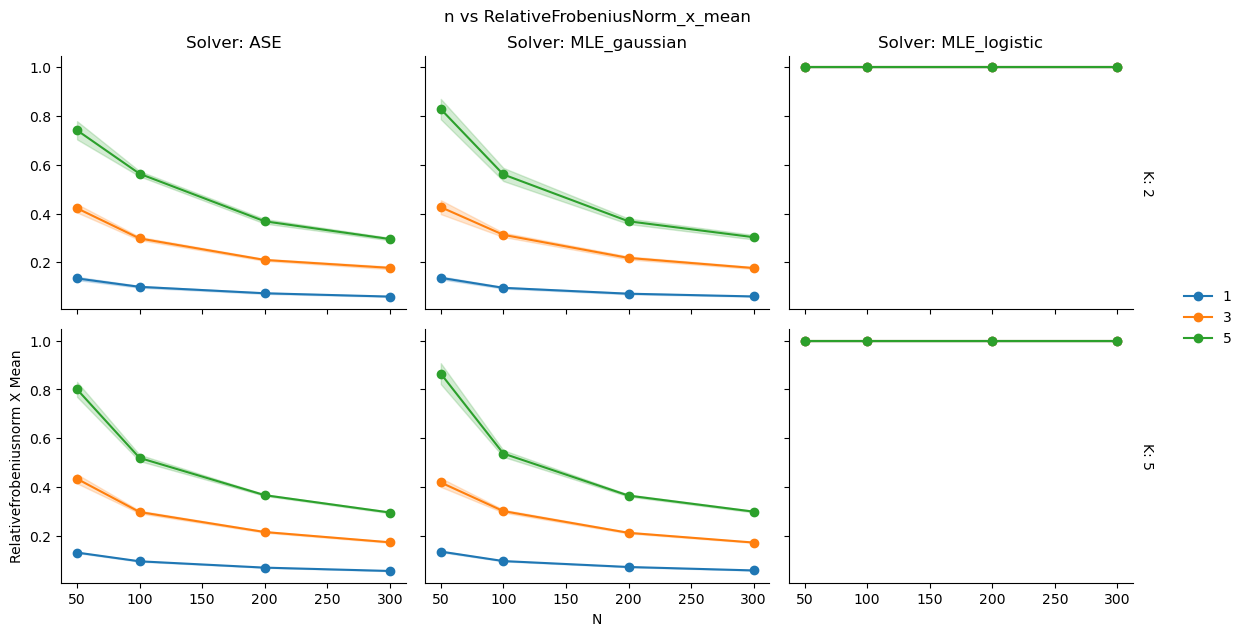

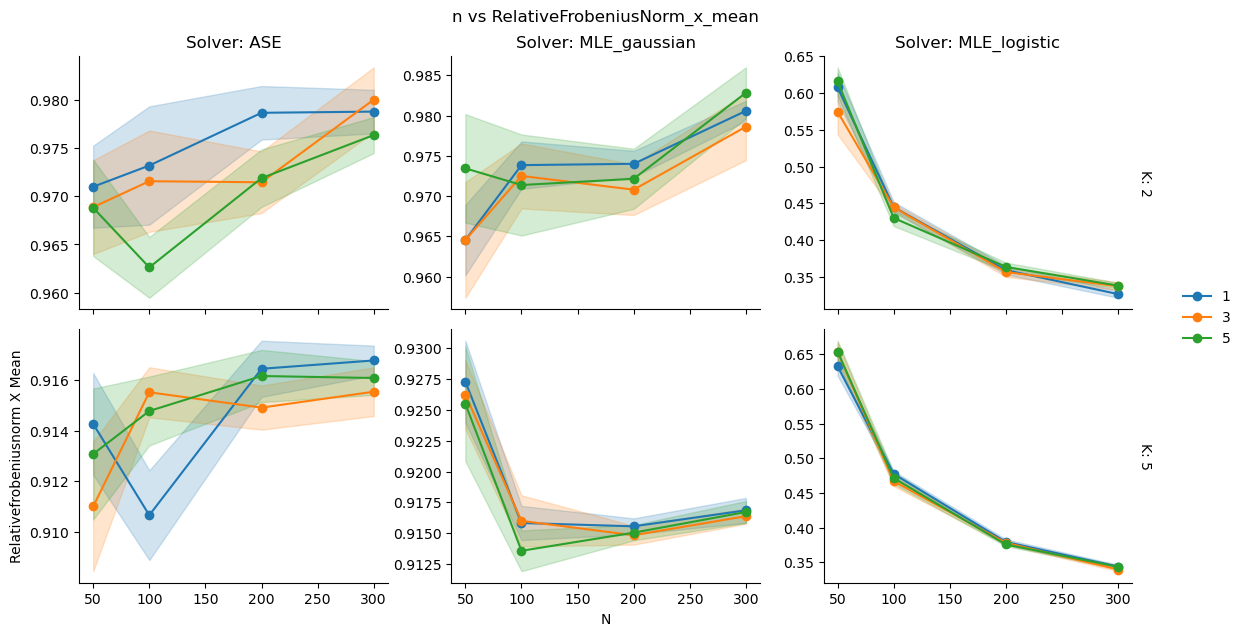

In [ ]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
        grouped_stats=agg_out_x_gaussian,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'solver', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=True
    )

plot_grid(
        grouped_stats=agg_out_x_bernoulli,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'solver', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False
    )

In [ ]:
1/0

def logistic_grad(params, X, y, mu=None):
    """Utility function for scipy optimizer returning loss and gradient for logistic regression"""
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w

def solve_logistic_scipy(X, y, mu=None):
    """Solve logistic regression with (possibly) fixed intercept and positive coefficients

    Parameters
    ----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target vector
    mu : float, optional
        Intercept term, by default None. If None estimate it

    Returns
    -------
    np.ndarray
        Coefficients of the logistic regression
    float
        Intercept term
    """
    
    n_samples, n_features = X.shape
    
    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y, mu),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)

    return res.x[:n_features], res.x[-1] if mu is None else mu

def MLE_logistic(A, k=2, rng=None, shrink=0, **kwargs):
    #print("WARNING: MLE_logistic is experimental and might not work as expected.")
    """Maximum Likelihood Estimation for Logistic link adjacency matrix

    Parameters
    ----------
    A : np.ndarray
        Adjacency matrix
    k : int, optional
        Number of latent dimensions, by default 2
    rng : np.random.Generator, optional
        Random number generator, by default None
    shrink : int, optional
        Shrinkage parameter, by default 0

    Returns
    -------
    _type_
        _description_
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # useful quantities
    n = A.shape[0]
    
    # in the paper it seems to use the frob norm NOT squared, i get better results
    # squaring it
    a_norm_scaled = 1/(n*(n-1)) * norm(A, 'fro')**2
    
    # mean centered matrix
    A_centered = A - a_norm_scaled
    
    # from paper, mle of \mu
    mu_hat = -np.log(a_norm_scaled/(1-a_norm_scaled))
    
    # use this to fix randomness in eigsh
    v0 = rng.standard_normal(size=A_centered.shape[0])

    evals, evectors = eigsh(A_centered, k=k, which='LM', v0=v0)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evectors = evectors[:, idx]

    # build the matrix of features
    X_big = np.zeros((n*(n-1)//2, k))

    for i in range(k):
        t = np.outer(evectors[:, i], evectors[:, i])
        X_big[:, i] = t[np.triu_indices(n, k=1)] 
    
    # define as target the upper diagonal part of A (equal to lower since 
    # A symmetric)
    target = A[np.triu_indices(n, k=1)]

    # solve logistic regression with fixed mu and positive constrained coefs
    coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    xhat = evectors * np.sqrt(coefs)
    
    return [xhat], [evals]

ZeroDivisionError: division by zero